# Delhi's revenue tree, Q1 against Q2

**Week 3, Wednesday. The trainer's parallel build, one notebook, run live in 60 minutes.** By the
end of it one city's revenue change is explained from the raw files, every number reproduces
from the top, and the claim carries its denominators and its caveat.

Dr Priya Menon, COO of Kalpa Health, opened the week with her own words: *"Test volumes grew
5 percent against a plan of 18, and I do not know which branch of my business is short."* Her
data team added two things they know: two cities changed booking systems in Q2, and the payment
feed keys invoices in its own format. Your group holds one of her five sub-problems. This
notebook holds a smaller one, Delhi's revenue from Q1 (April to June) to Q2 (July to
September), solved in the open so the method is on the page and the finds stay with the groups.

> **Kavya's review.** Before anything leaves the team: show me the count you started from, every
> row you set aside and why, and a second way to reach the same total.

Monday mapped each sub-problem onto the Week 1 and 2 method. This notebook runs that method once,
end to end, on files nobody in the room has cleaned before.

The next cell finds the shared helper by walking up from this folder, then reads two of the
Kalpa Health files from Monday's data folder, `../../D1/data/`, with pandas. Every value is read
as text, so nothing is converted before it has been looked at.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit

import pandas as pd

DATA = pathlib.Path("../../D1/data")
raw_bookings = pd.read_csv(DATA / "C2_W03_D01_bookings_legacy_STUDENT.csv", dtype=str, keep_default_na=False)
raw_invoices = pd.read_csv(DATA / "C2_W03_D01_invoices_STUDENT.csv", dtype=str, keep_default_na=False)

# The slice: Delhi only. A group profiles its whole file; this build profiles the rows it uses.
bookings = raw_bookings[raw_bookings["city"] == "Delhi"].copy()
invoices = raw_invoices[raw_invoices["city"] == "Delhi"].copy()

def quarter(dates):
    """Kalpa's Q1 is April to June and Q2 is July to September, read from the ISO date text."""
    return dates.map(lambda d: "Q1" if d < "2026-07-01" else "Q2")

bookings["quarter"] = quarter(bookings["booking_date"])
invoices["quarter"] = quarter(invoices["invoice_date"])
STEPS = ["profile\nand the identity rule", "amounts\nevery one converts", "reconcile\nbookings to invoices",
         "the tree\nQ1 against Q2", "the claim\nand its caveat"]
print(f"Delhi rows read: {len(bookings):,} from the old booking export, {len(invoices):,} from the invoices")

Delhi rows read: 2,128 from the old booking export, 2,032 from the invoices


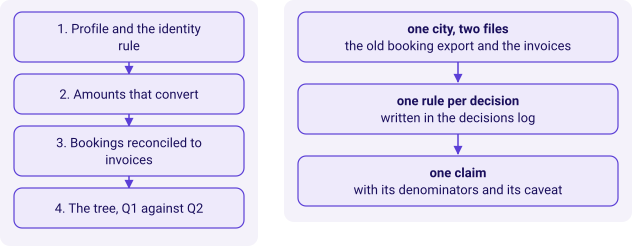

In [2]:
kit.side_by_side(
    kit.ladder(["Profile and the identity rule", "Amounts that convert", "Bookings reconciled to invoices",
                "The tree, Q1 against Q2"], lit=None, show=False),
    kit.vflow(["one city, two files\nthe old booking export and the invoices",
               "one rule per decision\nwritten in the decisions log",
               "one claim\nwith its denominators and its caveat"], show=False),
)

## 1. Profile before touching: a row is not yet a booking

The claim at this level is that the file's row count and its booking count are two different
numbers until an identity rule makes them one. The old booking export holds 2,128 Delhi rows. A
hurried count calls that 2,128 bookings and moves on, and every rate built on it inherits the
error.

**Predict before you run.** How many Delhi bookings does the old export hold?
- a) exactly 2,128, one per row
- b) fewer than 2,128
- c) more than 2,128, since cancelled bookings sit elsewhere
- d) no way to tell until the invoice file has been read

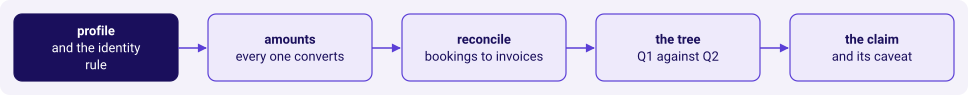

In [3]:
kit.flow(STEPS, lit=0)

In [4]:
def profile(df, columns):
    """Per column: filled, blank, distinct values, and one example, which is the Week 1 profile."""
    rows = []
    for c in columns:
        filled = (df[c] != "").sum()
        rows.append([c, f"{filled:,}", f"{len(df) - filled:,}", f"{df[c].nunique():,}", df[c].iloc[0]])
    return rows

kit.table(["Column", "Filled", "Blank", "Distinct", "Example"],
          profile(bookings, ["booking_id", "patient_id", "clinic_code", "booking_date", "channel", "status", "updated_at"]),
          caption=f"The old booking export, Delhi rows: {len(bookings):,}")
kit.table(["Column", "Filled", "Blank", "Distinct", "Example"],
          profile(invoices, ["invoice_no", "booking_id", "invoice_date", "amount"]),
          caption=f"The invoices, Delhi rows: {len(invoices):,}. The tree reads these four columns.")

Column,Filled,Blank,Distinct,Example
booking_id,"2,128",0,"2,095",KB0002971
patient_id,"2,128",0,952,P-003269
clinic_code,"2,128",0,3,KH-DEL-02
booking_date,"2,128",0,183,2026-05-18
channel,"2,085",43,5,walk-in
status,"2,128",0,2,completed
updated_at,"2,128",0,"2,080",2026-05-18 19:17


Column,Filled,Blank,Distinct,Example
invoice_no,"2,032",0,"2,032",KH/26-27/000033
booking_id,"2,032",0,"2,032",KB0000033
invoice_date,"2,032",0,183,2026-04-01
amount,"2,032",0,122,1800


**What happened.** The answer is b. The export holds 2,128 Delhi rows and 2,095 distinct
`booking_id` values, so 33 ids appear on two rows. The invoice file is clean on the same test:
2,032 rows and 2,032 distinct invoice numbers. `channel` is blank on 43 rows; this tree splits by
clinic, so that column is logged as not used rather than cleaned. The amounts profile as text,
which the next level deals with.

In [5]:
distinct_ids = bookings["booking_id"].nunique()
kit.check("the export holds more rows than distinct booking ids", len(bookings) > distinct_ids,
          f"{len(bookings):,} rows, {distinct_ids:,} distinct ids")
kit.check("every invoice number appears once", invoices["invoice_no"].is_unique, f"{len(invoices):,} invoices")
kit.check("every Delhi row carries a date and a status",
          (bookings["booking_date"] != "").all() and (bookings["status"] != "").all())

**The plausible wrong answer.** Count rows per quarter and call them bookings. Delhi then grows
from 1,039 to 1,089, a rise of 4.8 percent, and that is the number a hurried analyst would send.

Count,Q1,Q2,Change
Rows in the export (the wrong answer),"1,039","1,089",+4.8%
Distinct booking ids,"1,013","1,082",+6.8%


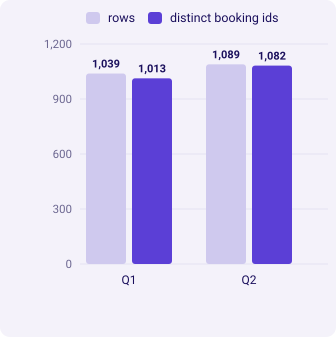

In [6]:
rows_q = bookings.groupby("quarter").size()
ids_q = bookings.groupby("quarter")["booking_id"].nunique()
wrong, right = rows_q["Q2"] / rows_q["Q1"] - 1, ids_q["Q2"] / ids_q["Q1"] - 1
kit.table(["Count", "Q1", "Q2", "Change"],
          [["Rows in the export (the wrong answer)", f"{rows_q['Q1']:,}", f"{rows_q['Q2']:,}", f"{wrong:+.1%}"],
           ["Distinct booking ids", f"{ids_q['Q1']:,}", f"{ids_q['Q2']:,}", f"{right:+.1%}"]],
          caption="Delhi, the old booking export")
kit.columns(["Q1", "Q2"], [("rows", [rows_q["Q1"], rows_q["Q2"]]),
                           ("distinct booking ids", [ids_q["Q1"], ids_q["Q2"]])])

**Why it is wrong.** The repeated ids are not spread evenly: 26 of the 33 extra rows sit in Q1
and 7 in Q2, so counting rows inflates the base quarter and makes Delhi look slower than it was.
A branch reported at 4.8 percent when it grew 6.8 percent could be the branch Dr Menon decides to
fix. The check that catches it is the one above: rows against distinct ids, per quarter.

**The identity rule.** One `booking_id` is one booking. Where two rows share an id, keep the row
with the later `updated_at`, since that is the system's latest word on the booking. Of the 33
pairs, 26 are identical in every field and 7 differ only in `updated_at`, so the rule decides
nothing it should not. Why a booking was exported twice is a question for Dr Menon's data team,
and it goes into the challenges log as a question; the rule does not depend on the answer.

In [7]:
pairs = bookings[bookings["booking_id"].duplicated(keep=False)].groupby("booking_id")
identical = sum(1 for _, g in pairs if len(g.drop_duplicates(subset=[c for c in g.columns if c != "quarter"])) == 1)
differs_only_in_updated = sum(1 for _, g in pairs
                              if len(g.drop_duplicates(subset=[c for c in g.columns if c != "quarter"])) == 2
                              and len(g.drop(columns=["updated_at"]).drop_duplicates()) == 1)

clean = (bookings.sort_values(["booking_id", "updated_at"])
                 .drop_duplicates("booking_id", keep="last"))
rejected = len(bookings) - len(clean)
kit.table(["Repeated ids", "Identical in every field", "Differ only in updated_at", "Rows set aside"],
          [[f"{pairs.ngroups}", f"{identical}", f"{differs_only_in_updated}", f"{rejected}"]],
          caption="What the identity rule decided")

Repeated ids,Identical in every field,Differ only in updated_at,Rows set aside
33,26,7,33


In [8]:
kit.check("input equals kept plus set aside", len(bookings) == len(clean) + rejected,
          f"{len(bookings):,} = {len(clean):,} + {rejected}")
kit.check("every repeated pair differs, if at all, only in updated_at",
          identical + differs_only_in_updated == pairs.ngroups, f"{identical} + {differs_only_in_updated}")
kit.check("the kept rows have one row per booking id", clean["booking_id"].is_unique)

## 2. Amounts: every rupee converts, or the total is short

The claim at this level is that revenue can only be summed once every amount is a number, and a
conversion that fails quietly is worse than one that fails loudly. The `amount` column was read
as text. The quick fix is `pd.to_numeric(..., errors="coerce")`, which turns anything it cannot
read into a blank and lets the sum carry on.

**Predict before you run.** What does the coerced sum do on Delhi's invoices?
- a) it stops with an error on the first amount it cannot read
- b) it matches the true total to the rupee, since coerce only changes the type
- c) it comes out short, because a few amounts become blanks
- d) it doubles, since a text amount is concatenated before the sum adds it

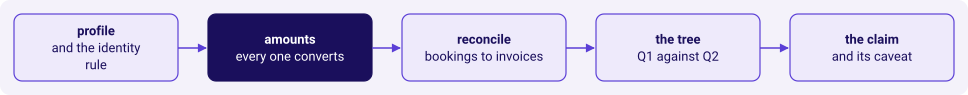

In [9]:
kit.flow(STEPS, lit=1)

In [10]:
coerced = pd.to_numeric(invoices["amount"], errors="coerce")
dropped = invoices[coerced.isna()]
wrong_total = coerced.groupby(invoices["quarter"]).sum()
kit.table(["What the coerced sum shows", "Q1", "Q2"],
          [["Revenue", kit.rupees(wrong_total["Q1"]), kit.rupees(wrong_total["Q2"])],
           ["Amounts turned into blanks", f"{(dropped['quarter'] == 'Q1').sum()}", f"{(dropped['quarter'] == 'Q2').sum()}"]],
          caption="The plausible wrong answer")
print("The amounts it could not read:", ", ".join(dropped["amount"]))

What the coerced sum shows,Q1,Q2
Revenue,"Rs 15,52,357","Rs 16,37,825"
Amounts turned into blanks,3,1


The amounts it could not read: 1,100, 1,499, 1,499, 1,950


**What happened.** The answer is c. Four amounts are written with a thousands comma, as a
spreadsheet prints them, and coerce turned each into a blank. The Q1 total comes out
Rs 4,098 short and Q2 Rs 1,950 short. **Why it is wrong.** Nothing on the screen says anything
was lost, so the finance head's books and this notebook would disagree by Rs 6,048 with no row to
point at. The check that catches it counts the amounts that failed to convert, which must be zero
before any total is read. The fix removes the comma and converts strictly, so any amount still
unreadable stops the run.

In [11]:
invoices["amount_rs"] = invoices["amount"].str.replace(",", "", regex=False).astype(int)
right_total = invoices.groupby("quarter")["amount_rs"].sum()
kit.table(["Revenue", "Q1", "Q2"],
          [["Coerced (wrong)", kit.rupees(wrong_total["Q1"]), kit.rupees(wrong_total["Q2"])],
           ["Every amount converted", kit.rupees(right_total["Q1"]), kit.rupees(right_total["Q2"])],
           ["What the blanks hid", kit.rupees(right_total["Q1"] - wrong_total["Q1"]),
            kit.rupees(right_total["Q2"] - wrong_total["Q2"])]],
          caption="Delhi invoices, the same rows summed two ways")

Revenue,Q1,Q2
Coerced (wrong),"Rs 15,52,357","Rs 16,37,825"
Every amount converted,"Rs 15,56,455","Rs 16,39,775"
What the blanks hid,"Rs 4,098","Rs 1,950"


In [12]:
kit.check("no amount is left unconverted", invoices["amount_rs"].notna().all(), f"{len(invoices):,} amounts")
kit.check("the fix recovers exactly what coerce dropped",
          int(right_total.sum() - wrong_total.sum()) == int(invoices.loc[dropped.index, "amount_rs"].sum()),
          kit.rupees(right_total.sum() - wrong_total.sum()))

## 3. Reconcile: every completed booking has one invoice, and nothing else has one

The claim at this level is that the invoice file and the booking export describe the same
bookings, and a join proves it only when it is checked in both directions and on its grain. A
hurried join puts the raw export beside the invoices on `booking_id` and sums the amounts.

**Predict before you run.** Joining the raw Delhi export to the Delhi invoices on `booking_id`
gives how many rows?
- a) 2,032, one per invoice
- b) 2,128, one per export row
- c) more than 2,032 but fewer than 2,128
- d) fewer than 2,032, since cancelled rows fall away

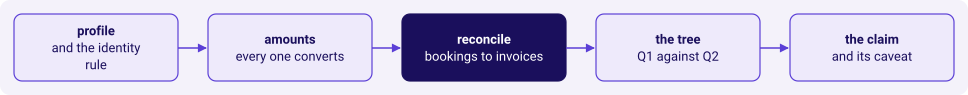

In [13]:
kit.flow(STEPS, lit=2)

In [14]:
fanned = bookings.merge(invoices, on="booking_id", suffixes=("", "_inv"))
kit.table(["Joined on the raw export", "Rows", "Revenue"],
          [["The plausible wrong answer", f"{len(fanned):,}", kit.rupees(fanned["amount_rs"].sum())],
           ["The invoices themselves", f"{len(invoices):,}", kit.rupees(invoices["amount_rs"].sum())]],
          caption="The same invoices, joined before and without the identity rule")

Joined on the raw export,Rows,Revenue
The plausible wrong answer,"2,065","Rs 32,43,653"
The invoices themselves,"2,032","Rs 31,96,230"


**What happened.** The answer is c: 2,065 rows. Each repeated booking that was completed carries
its invoice twice, so the joined revenue reads Rs 32,43,653 against Rs 31,96,230 in the invoice
file, Rs 47,423 too much, with most of it landing in Q1. **Why it is wrong.** The join changed
the grain from one row per invoice to one row per export row without saying so, which is the
Week 2 fan-out. The check that catches it is `validate="one_to_one"`, which refuses the join the
moment either side repeats a key.

In [15]:
with kit.expect_error() as err:
    bookings.merge(invoices, on="booking_id", validate="one_to_one")
kit.check("the unchecked join is refused on its grain", err.name == "MergeError", err.message)

The fix joins the kept rows, with the grain declared, and keeps both sides visible with an
outer join, so a booking with no invoice and an invoice with no booking would each show up
rather than vanish. Then the reconciliation is written down as arithmetic: rows read, rows set
aside, bookings kept, bookings cancelled, bookings completed, invoices matched.

Step,Rows
Rows read from the old export,"2,128"
Set aside by the identity rule,33
Bookings kept,"2,095"
"of which cancelled, no invoice expected",63
of which completed,"2,032"
Completed bookings matched to one invoice,"2,032"
Invoices with no booking in the export,0
Bookings with an invoice though cancelled,0


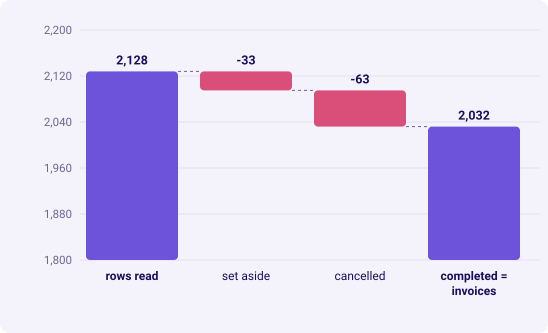

In [16]:
joined = clean.merge(invoices, on="booking_id", how="outer", validate="one_to_one",
                     suffixes=("", "_inv"), indicator=True)
side = joined["_merge"].value_counts()
completed = clean[clean["status"] == "completed"]
cancelled = clean[clean["status"] == "cancelled"]
matched = joined[joined["_merge"] == "both"]
kit.table(["Step", "Rows"],
          [["Rows read from the old export", f"{len(bookings):,}"],
           ["Set aside by the identity rule", f"{rejected}"],
           ["Bookings kept", f"{len(clean):,}"],
           ["of which cancelled, no invoice expected", f"{len(cancelled)}"],
           ["of which completed", f"{len(completed):,}"],
           ["Completed bookings matched to one invoice", f"{(matched['status'] == 'completed').sum():,}"],
           ["Invoices with no booking in the export", f"{side.get('right_only', 0)}"],
           ["Bookings with an invoice though cancelled", f"{(matched['status'] == 'cancelled').sum()}"]],
          caption="Delhi, Q1 and Q2 together")
kit.bridge(("rows read", len(bookings)),
           [("set aside", -rejected), ("cancelled", -len(cancelled))],
           end_label="completed = invoices", fmt=lambda v: f"{v:,.0f}", lo=1800)

In [17]:
kit.check("rows read equal kept plus set aside", len(bookings) == len(clean) + rejected)
kit.check("every completed booking has exactly one invoice",
          (matched["status"] == "completed").sum() == len(completed) == len(invoices),
          f"{len(completed):,} completed, {len(invoices):,} invoices")
kit.check("no invoice lacks a booking, and no cancelled booking is invoiced",
          side.get("right_only", 0) == 0 and (matched["status"] == "cancelled").sum() == 0)

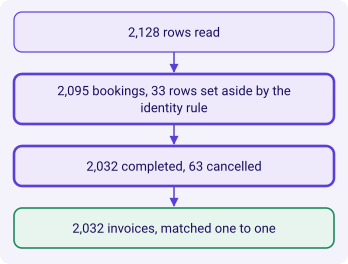

What the build can now say,The evidence
"Delhi's old export holds 2,095 bookings in 2,128 rows","33 repeated ids, 26 identical, 7 differing only in updated_at"
Every Delhi amount is a number,"4 comma-written amounts converted, none left blank"
"Invoices and completed bookings are the same 2,032","outer join, one to one, nothing on either side unmatched"


In [18]:
kit.vflow(["2,128 rows read", "2,095 bookings, 33 rows set aside by the identity rule",
           "2,032 completed, 63 cancelled", "2,032 invoices, matched one to one"],
          kinds=["plain", "known", "known", "good"])
kit.table(["What the build can now say", "The evidence"],
          [["Delhi's old export holds 2,095 bookings in 2,128 rows", "33 repeated ids, 26 identical, 7 differing only in updated_at"],
           ["Every Delhi amount is a number", "4 comma-written amounts converted, none left blank"],
           ["Invoices and completed bookings are the same 2,032", "outer join, one to one, nothing on either side unmatched"]],
          caption="What the first three levels established")

## 4. The tree: more invoices at a lower mean moved Delhi's revenue

The claim at this level is that Delhi's revenue change splits into how many invoices were raised
and what each was worth on average, and that each leaf is read against its own denominator.
Revenue is invoices multiplied by the mean invoice; invoices are completed bookings. This is the
Week 1 tree, with a booking in place of an order and an invoice in place of a bill.

**Predict before you run.** Delhi's revenue rose from Q1 to Q2. Which leaf moved it?
- a) more invoices, each worth less on average
- b) fewer invoices, each worth more on average
- c) more invoices, each worth more on average
- d) the same number of invoices, each worth more on average

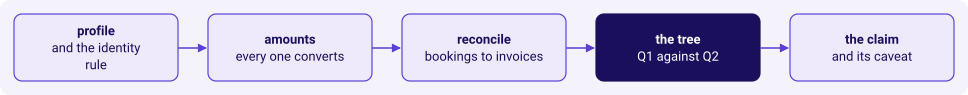

In [19]:
kit.flow(STEPS, lit=3)

Leaf,Q1,Q2,Change
Revenue,"Rs 15,56,455","Rs 16,39,775",+5.4%
Invoices (completed bookings),977,"1,055",+8.0%
Mean invoice,"Rs 1,593","Rs 1,554",-2.4%
Median invoice,"Rs 1,499","Rs 1,400",-6.6%


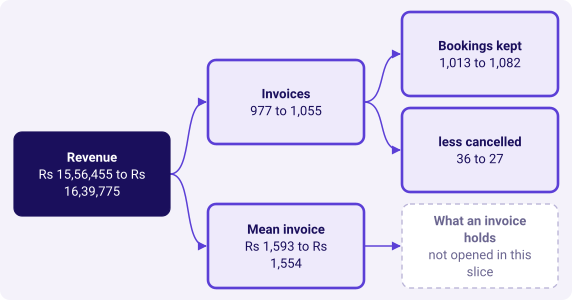

In [20]:
tree = invoices.groupby("quarter")["amount_rs"].agg(["count", "sum", "mean", "median"])
q1, q2 = tree.loc["Q1"], tree.loc["Q2"]
kept_q = clean.groupby("quarter").size()
cancel_q = clean[clean["status"] == "cancelled"].groupby("quarter").size()
def move(a, b):
    return f"{b / a - 1:+.1%}"
kit.table(["Leaf", "Q1", "Q2", "Change"],
          [["Revenue", kit.rupees(q1["sum"]), kit.rupees(q2["sum"]), move(q1["sum"], q2["sum"])],
           ["Invoices (completed bookings)", f"{int(q1['count']):,}", f"{int(q2['count']):,}", move(q1["count"], q2["count"])],
           ["Mean invoice", kit.rupees(round(q1["mean"])), kit.rupees(round(q2["mean"])), move(q1["mean"], q2["mean"])],
           ["Median invoice", kit.rupees(q1["median"]), kit.rupees(q2["median"]), move(q1["median"], q2["median"])]],
          caption="Delhi, from the invoices, after levels 1 to 3")
kit.driver_tree({"label": "Revenue", "note": f"{kit.rupees(q1['sum'])} to {kit.rupees(q2['sum'])}", "kind": "lit",
                 "children": [
                     {"label": "Invoices", "note": f"{int(q1['count']):,} to {int(q2['count']):,}", "kind": "known",
                      "children": [{"label": "Bookings kept", "note": f"{kept_q['Q1']:,} to {kept_q['Q2']:,}", "kind": "known"},
                                   {"label": "less cancelled", "note": f"{cancel_q['Q1']} to {cancel_q['Q2']}", "kind": "known"}]},
                     {"label": "Mean invoice", "note": f"{kit.rupees(round(q1['mean']))} to {kit.rupees(round(q2['mean']))}",
                      "kind": "known",
                      "children": [{"label": "What an invoice holds", "note": "not opened in this slice", "kind": "unknown"}]}]})

**What happened.** The answer is a. Invoices rose 8.0 percent and the mean invoice fell 2.4
percent, so revenue rose 5.4 percent, from Rs 15,56,455 to Rs 16,39,775. A bridge splits the
Rs 83,320 into its two leaves: the extra 78 invoices at Q1's mean add Rs 1,24,262, and Q2's lower
mean across all 1,055 invoices takes away Rs 40,942.

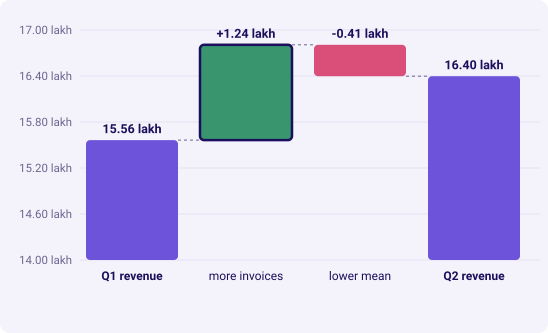

In [21]:
volume = (q2["count"] - q1["count"]) * q1["mean"]
value = q2["count"] * (q2["mean"] - q1["mean"])
kit.bridge(("Q1 revenue", q1["sum"]), [("more invoices", round(volume)), ("lower mean", round(value))],
           end_label="Q2 revenue", lit=[0], lo=1400000, fmt=lambda v: f"{v / 100000:.2f} lakh")
kit.check("the two leaves add up to the change in revenue", round(volume + value) == round(q2["sum"] - q1["sum"]),
          f"{kit.rupees(round(volume))} and {kit.rupees(round(value))}")
kit.check("more invoices and a lower mean, as predicted", q2["count"] > q1["count"] and q2["mean"] < q1["mean"])

**The plausible wrong answer.** "Delhi raised 8.0 percent more invoices in Q2." It is true of the
totals and wrong as a rate. **Why it is wrong.** Q1 runs 91 days and Q2 runs 92, so one extra
day of trading is inside the 8.0 percent. Per day, invoices rose 6.8 percent and revenue 4.2
percent. A comparison against a plan set per month or per day needs the per-day figure, and a
claim that quotes totals has to say the windows differ. The check compares the two windows'
lengths before any rate is written.

In [22]:
days = {"Q1": 91, "Q2": 92}
kit.check("the two quarters are different lengths", days["Q1"] != days["Q2"], "91 and 92 days")
per_day = {q: (tree.loc[q, "count"] / days[q], tree.loc[q, "sum"] / days[q]) for q in days}
kit.table(["Per day", "Q1", "Q2", "Change"],
          [["Invoices", f"{per_day['Q1'][0]:.2f}", f"{per_day['Q2'][0]:.2f}", move(per_day["Q1"][0], per_day["Q2"][0])],
           ["Revenue", kit.rupees(round(per_day["Q1"][1])), kit.rupees(round(per_day["Q2"][1])), move(per_day["Q1"][1], per_day["Q2"][1])]],
          caption="Delhi, the same totals over 91 and 92 days")

Per day,Q1,Q2,Change
Invoices,10.74,11.47,+6.8%
Revenue,"Rs 17,104","Rs 17,824",+4.2%


The last split this slice makes is by clinic, because `clinic_code` sits on the booking and
every Delhi booking carries one. It says where inside Delhi the extra invoices were raised. The
split stops there. Below the mean invoice sits what each invoice holds, and why the mean fell is
a question the invoice file cannot answer on its own; it goes into the challenges log as a
question for the branch below, which this slice does not open.

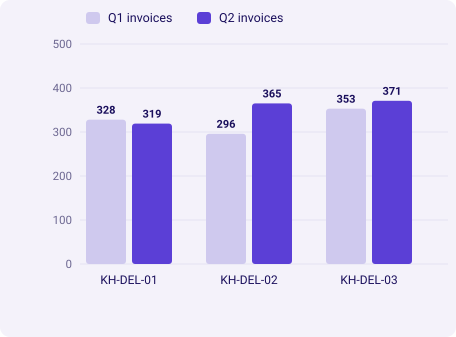

Clinic,Q1 invoices,Q2 invoices,Q1 revenue,Q2 revenue
KH-DEL-01,328,319,"Rs 5,06,451","Rs 4,92,265"
KH-DEL-02,296,365,"Rs 4,71,790","Rs 5,80,466"
KH-DEL-03,353,371,"Rs 5,78,214","Rs 5,67,044"


In [23]:
by_clinic = clean.merge(invoices, on="booking_id", validate="one_to_one", suffixes=("", "_inv")).groupby(["clinic_code", "quarter"])["amount_rs"].agg(["count", "sum"])
clinics = sorted(clean["clinic_code"].unique())
kit.columns(clinics, [("Q1 invoices", [by_clinic.loc[(c, "Q1"), "count"] for c in clinics]),
                      ("Q2 invoices", [by_clinic.loc[(c, "Q2"), "count"] for c in clinics])])
kit.table(["Clinic", "Q1 invoices", "Q2 invoices", "Q1 revenue", "Q2 revenue"],
          [[c, f"{by_clinic.loc[(c, 'Q1'), 'count']:,}", f"{by_clinic.loc[(c, 'Q2'), 'count']:,}",
            kit.rupees(by_clinic.loc[(c, "Q1"), "sum"]), kit.rupees(by_clinic.loc[(c, "Q2"), "sum"])] for c in clinics],
          caption="Delhi by clinic, from the kept bookings joined to their invoices")
kit.check("the clinic leaves add back to the city total", int(by_clinic["sum"].sum()) == int(invoices["amount_rs"].sum()),
          kit.rupees(by_clinic["sum"].sum()))

## The claim, the decisions log and where this build stops

The claim is written in the Week 1 Thursday shape, claim first, so it survives being read for
two minutes and put down.

| Part | Delhi, Q1 against Q2 |
|---|---|
| **Claim** | Delhi's invoiced revenue rose 5.4 percent, from Rs 15,56,455 on 977 invoices in Q1 to Rs 16,39,775 on 1,055 in Q2, because it raised more invoices at a slightly lower mean. |
| **Evidence** | 2,128 rows of the old export reduced to 2,095 bookings by one identity rule; the 2,032 completed ones matched one to one to 2,032 invoices; revenue split into 78 more invoices (plus Rs 1,24,262) and a mean Rs 39 lower (minus Rs 40,942). |
| **Caveat** | This is invoiced revenue, which is not the same as money collected, and Q2 is one day longer than Q1: per day, revenue rose 4.2 percent. Why the mean invoice fell is not yet known. |
| **Action** | Treat Delhi as growing modestly on volume, and open the branch below the invoice before deciding whether the lower mean is a price, a mix or a fee question. |

The decisions log follows the Week 1 Wednesday shape, one row per decision, and it includes a row
that was kept.

Field,Issue,Rows,Decision,Reason
booking_id,33 ids appear on two rows,33,Keep the row with the later updated_at,"One id is one booking; 26 pairs are identical and 7 differ only in updated_at, so no booking fact is lost"
amount,4 amounts written with a thousands comma,4,"Remove the comma, convert strictly","Coerce would blank them and leave revenue Rs 6,048 short with no error"
channel,Blank on 43 rows,43,Kept as they are,"This tree splits by clinic, so the blanks change no number here; logged for any channel split"
status,63 cancelled bookings carry no invoice,63,"Kept, outside revenue",A cancelled booking is a real booking that earns nothing; the reconciliation shows each one


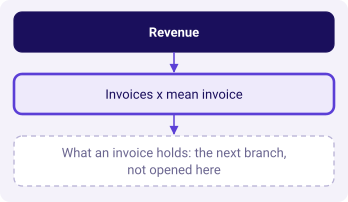

In [24]:
kit.table(["Field", "Issue", "Rows", "Decision", "Reason"],
          [["booking_id", "33 ids appear on two rows", "33", "Keep the row with the later updated_at",
            "One id is one booking; 26 pairs are identical and 7 differ only in updated_at, so no booking fact is lost"],
           ["amount", "4 amounts written with a thousands comma", "4", "Remove the comma, convert strictly",
            "Coerce would blank them and leave revenue Rs 6,048 short with no error"],
           ["channel", "Blank on 43 rows", "43", "Kept as they are",
            "This tree splits by clinic, so the blanks change no number here; logged for any channel split"],
           ["status", "63 cancelled bookings carry no invoice", "63", "Kept, outside revenue",
            "A cancelled booking is a real booking that earns nothing; the reconciliation shows each one"]],
          caption="The decisions log for the Delhi slice")
kit.vflow(["Revenue", "Invoices x mean invoice", "What an invoice holds: the next branch, not opened here"],
          kinds=["lit", "known", "unknown"])

### In the interview

**[F] Two systems export the same entity with different id formats; how do you reconcile them?**
Write one rule that turns each format into a single canonical key, and apply it to both sides
rather than editing either export. Prove the rule on the rows: report how many matched before
and after, then anti-join in both directions and classify every leftover, because an unmatched
row is either a real gap or a defect in the rule. Check the grain on the way, so a key repeated on
one side is caught before it doubles a total, and write the rule in the decisions log so the
finance head can rerun it.

**[D] State your finding in one sentence a COO can carry into a board meeting.** The claim above
is the model: the number, its two denominators, the period, and the reason, in one sentence,
with the caveat one line below it and never folded into it.

> **Kavya's review.** The count you started from is on the page, every row set aside has a
> reason, and the clinics add back to the city. The second way to the same total is the bridge.

In [25]:
kit.check_summary()
print("Next: your group's own cut, run the same way, with its claim ready for the close.")

Next: your group's own cut, run the same way, with its claim ready for the close.
